In [1]:
import os
import datetime
import warnings
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from sklearn.metrics import mean_absolute_error
from models import create_arcface_model

warnings.filterwarnings('ignore')
print('TensorFlow version:', tf.__version__)



TensorFlow version: 2.15.0


In [2]:
train_ds = tf.data.Dataset.load(r'data\\videoface_100\\train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.load(r'data\\videoface_100\\val_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, valid_ds


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>)

Load Arcface


In [3]:
# ── [Cell 3] Verifikasi: Load ArcFace pre-trained weights ──────────────────
# Cell ini hanya untuk memastikan create_arcface_model() berjalan dengan benar.
# arcface_112 yang dibuat di sini akan DIGUNAKAN LANGSUNG di Cell 4.
arcface_112 = create_arcface_model(load_weights=True)
arcface_112.trainable = False

print(f'\nArcFace output shape: {arcface_112.output_shape}')  # Harusnya (None, 512)
print(f'Jumlah layer ArcFace : {len(arcface_112.layers)}')
print(f'Trainable            : {arcface_112.trainable}')




✓ ArcFace weights berhasil dimuat dari: c:\Users\ALFIAN\TA_CODING\ZIP_FILE\arcface_oceanmodel\ocean-project-deepface\arcface_weights.h5

ArcFace output shape: (None, 512)
Jumlah layer ArcFace : 163
Trainable            : False


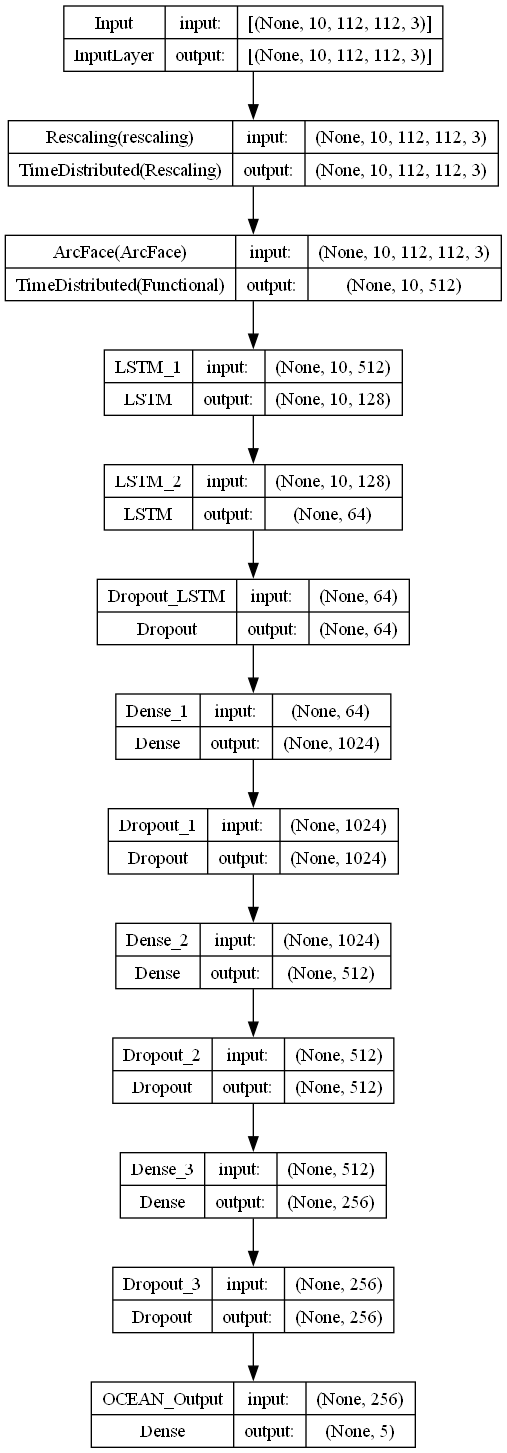

In [4]:
# ── [Cell 4] Bangun model prediksi kepribadian OCEAN ───────────────────────
# CATATAN: arcface_112 sudah di-load di Cell 3, tidak perlu di-load ulang.

inputs = keras.layers.Input(shape=(10, 112, 112, 3), name='Input')

# Rescale [0,255] -> [0,1]
x = keras.layers.TimeDistributed(
    keras.layers.Rescaling(scale=1./255.0), name='Rescaling'
)(inputs)

# Ekstrak ArcFace embedding per-frame -> (batch, 10, 512)
x = keras.layers.TimeDistributed(arcface_112, name='ArcFace')(x)

# Temporal modelling dengan LSTM
x = keras.layers.LSTM(units=128, return_sequences=True, name='LSTM_1')(x)
x = keras.layers.LSTM(units=64, name='LSTM_2')(x)
x = keras.layers.Dropout(0.2, name='Dropout_LSTM')(x)

# Dense head
x = keras.layers.Dense(1024, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01), name='Dense_1')(x)
x = keras.layers.Dropout(0.3, name='Dropout_1')(x)

x = keras.layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01), name='Dense_2')(x)
x = keras.layers.Dropout(0.3, name='Dropout_2')(x)

x = keras.layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01), name='Dense_3')(x)
x = keras.layers.Dropout(0.5, name='Dropout_3')(x)

# Output: 5 trait OCEAN, nilai antara 0-1
output = keras.layers.Dense(5, activation='sigmoid', name='OCEAN_Output')(x)

model = keras.models.Model(inputs=inputs, outputs=output, name='ArcFace_OCEAN_RMSprop')
keras.utils.plot_model(model, show_shapes=True)


In [6]:
# ── [Cell 5] Setup training — Optimizer: RMSprop ─────────────────
t = datetime.datetime.now().strftime('%m%d_%H%M%S')

optimizer = keras.optimizers.RMSprop()

os.makedirs(f'./weights/faces/{t}', exist_ok=True)
weight_path = f'./weights/faces/{t}/face.h5'

early_stopping = keras.callbacks.EarlyStopping(
    patience=10, verbose=1, restore_best_weights=True
)
check_point = keras.callbacks.ModelCheckpoint(
    filepath=weight_path,
    monitor='val_mae',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    save_format='h5',
    verbose=1
)

model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])
print(f'Optimizer       : {optimizer}')
print(f'Weights path    : {weight_path}')


Optimizer       : <keras.src.optimizers.rmsprop.RMSprop object at 0x0000012FB08968C0>
Weights path    : ./weights/faces/0415_140639/face.h5


In [7]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=100,
    callbacks=[early_stopping, check_point]
)


Epoch 1/100


8/8 [==============================] - ETA: 0s - loss: 9.0884 - mae: 0.1379
Epoch 1: val_mae improved from inf to 0.13039, saving model to ./weights/faces/0415_140639\face.h5
8/8 [==============================] - 32s 3s/step - loss: 9.0884 - mae: 0.1379 - val_loss: 6.8147 - val_mae: 0.1304
Epoch 2/100
8/8 [==============================] - ETA: 0s - loss: 5.7653 - mae: 0.1355
Epoch 2: val_mae improved from 0.13039 to 0.12841, saving model to ./weights/faces/0415_140639\face.h5
8/8 [==============================] - 22s 3s/step - loss: 5.7653 - mae: 0.1355 - val_loss: 4.5270 - val_mae: 0.1284
Epoch 3/100
8/8 [==============================] - ETA: 0s - loss: 3.7925 - mae: 0.1342
Epoch 3: val_mae improved from 0.12841 to 0.12723, saving model to ./weights/faces/0415_140639\face.h5
8/8 [==============================] - 21s 3s/step - loss: 3.7925 - mae: 0.1342 - val_loss: 3.0105 - val_mae: 0.1272
Epoch 4/100
8/8 [==============================] - ETA: 0s - loss: 2.5563 - ma

### Load weights

In [8]:
# ── [Cell 8] Load weights (OPSIONAL) ──────────────────────────────────────
# PERHATIAN: Jalankan cell ini HANYA jika:
#   - Kamu mau load ulang weights tanpa training dari awal
#   - Atau kernel restart setelah training selesai
#
# Jika baru selesai training (Cell 6 baru dijalankan),
# LEWATI cell ini -- model di memori sudah punya weights terbaik.
#
# Jika perlu load ulang, uncomment baris di bawah dan sesuaikan path:
# model.load_weights(f'weights/faces/{t}/face.h5')
# print(f'Weights di-load dari: weights/faces/{t}/face.h5')
print('Cell 8 di-skip. Model menggunakan weights hasil training terbaru.')


Cell 8 di-skip. Model menggunakan weights hasil training terbaru.


In [9]:
# ── [Cell 8b] Simpan full model untuk deployment Flask ─────────────────────
full_model_path = f'weights/faces/{t}/face_full_model.h5'
model.save(full_model_path)
print(f'Full model disimpan ke: {full_model_path}')
print('Gunakan di Flask: keras.models.load_model(path)')


Full model disimpan ke: weights/faces/0415_140639/face_full_model.h5
Gunakan di Flask: keras.models.load_model(path)


## Evaluation

### Training data

In [10]:
train_ds = tf.data.Dataset.load(r'data\videoface_100\train_ds') 
loss, mae = model.evaluate(train_ds)
(1-mae)*100

8/8 [==============================] - 17s 2s/step - loss: 0.0270 - mae: 0.1278


87.21874803304672

In [11]:
y_true = np.concatenate([y for x,y in train_ds])
y_pred = model.predict(train_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

8/8 [==============================] - 18s 2s/step


(array([88.51852, 85.24272, 87.4838 , 88.59463, 86.25408], dtype=float32),
 87.21874803304672)

### Validation data

In [12]:
valid_ds = tf.data.Dataset.load(r'data\videoface_100\val_ds') 
loss, mae = model.evaluate(valid_ds)
(1-mae)*100

3/3 [==============================] - 6s 2s/step - loss: 0.0178 - mae: 0.1172


88.27932253479958

In [13]:
y_true = np.concatenate([y for x,y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 6s 2s/step


(array([88.829765, 87.36333 , 88.77687 , 90.4923  , 85.93436 ],
       dtype=float32),
 88.27932327985764)

### Test data

In [14]:
test_ds = tf.data.Dataset.load(r'data\videoface_100\test_ds')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

3/3 [==============================] - 6s 2s/step - loss: 0.0310 - mae: 0.1397


86.03234738111496

In [15]:
y_true = np.concatenate([y for x,y in test_ds])
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 6s 2s/step


(array([88.44444, 84.02913, 87.30677, 87.08791, 83.29349], dtype=float32),
 86.03234738111496)

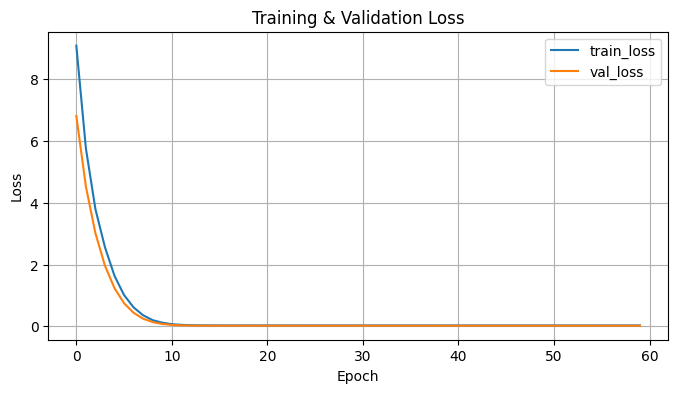

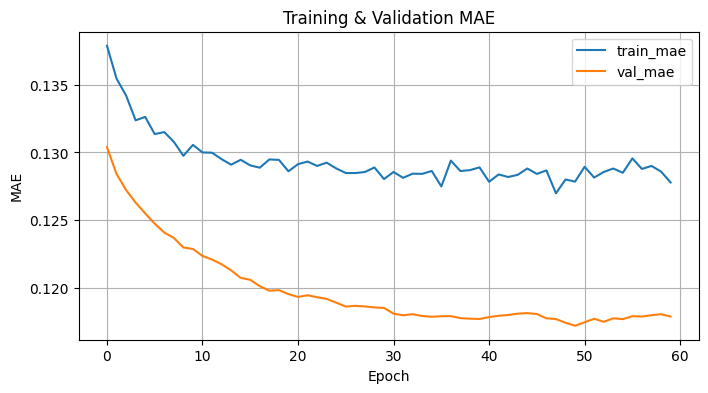

In [16]:
import matplotlib.pyplot as plt

# 1) Plot Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot MAE (atau metric lain yang kamu pakai)
plt.figure(figsize=(8,4))
plt.plot(history.history['mae'],     label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

---
## Evaluasi Tambahan


In [17]:
# ── [Eval 1] Tabel Ringkasan Per Trait OCEAN ─────────────────────────────
import pandas as pd

TRAITS = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

def compute_summary(ds):
    y_true_list, y_pred_list = [], []
    for x_batch, y_batch in ds:
        y_true_list.append(y_batch.numpy())
        y_pred_list.append(model.predict(x_batch, verbose=0))
    yt = np.vstack(y_true_list)
    yp = np.vstack(y_pred_list)
    mae = np.abs(yt - yp).mean(axis=0)
    acc = (1 - mae) * 100
    return mae, acc

train_ds_e = tf.data.Dataset.load(r'data\\videoface_100\\train_ds')
valid_ds_e = tf.data.Dataset.load(r'data\\videoface_100\\val_ds')
test_ds_e  = tf.data.Dataset.load(r'data\\videoface_100\\test_ds')

mae_tr, acc_tr = compute_summary(train_ds_e)
mae_vl, acc_vl = compute_summary(valid_ds_e)
mae_te, acc_te = compute_summary(test_ds_e)

rows = []
for i, trait in enumerate(TRAITS):
    rows.append({'Trait': trait,
                 'MAE Train': f'{mae_tr[i]:.4f}', 'Acc Train (%)': f'{acc_tr[i]:.2f}',
                 'MAE Val'  : f'{mae_vl[i]:.4f}', 'Acc Val (%)'  : f'{acc_vl[i]:.2f}',
                 'MAE Test' : f'{mae_te[i]:.4f}', 'Acc Test (%)' : f'{acc_te[i]:.2f}'})
rows.append({'Trait': 'RATA-RATA',
             'MAE Train': f'{mae_tr.mean():.4f}', 'Acc Train (%)': f'{acc_tr.mean():.2f}',
             'MAE Val'  : f'{mae_vl.mean():.4f}', 'Acc Val (%)'  : f'{acc_vl.mean():.2f}',
             'MAE Test' : f'{mae_te.mean():.4f}', 'Acc Test (%)' : f'{acc_te.mean():.2f}'})

df_summary = pd.DataFrame(rows).set_index('Trait')
print('\n=== Tabel Ringkasan Evaluasi Per Trait OCEAN ===')
print(df_summary.to_string())
df_summary



=== Tabel Ringkasan Evaluasi Per Trait OCEAN ===
                  MAE Train Acc Train (%) MAE Val Acc Val (%) MAE Test Acc Test (%)
Trait                                                                              
Openness             0.1148         88.52  0.1117       88.83   0.1156        88.44
Conscientiousness    0.1476         85.24  0.1264       87.36   0.1597        84.03
Extraversion         0.1252         87.48  0.1122       88.78   0.1269        87.31
Agreeableness        0.1141         88.59  0.0951       90.49   0.1291        87.09
Neuroticism          0.1375         86.25  0.1407       85.93   0.1671        83.29
RATA-RATA            0.1278         87.22  0.1172       88.28   0.1397        86.03


,MAE Train,Acc Train (%),MAE Val,Acc Val (%),MAE Test,Acc Test (%)
Trait,,,,,,
Openness,0.1148,88.52,0.1117,88.83,0.1156,88.44
Conscientiousness,0.1476,85.24,0.1264,87.36,0.1597,84.03
Extraversion,0.1252,87.48,0.1122,88.78,0.1269,87.31
Agreeableness,0.1141,88.59,0.0951,90.49,0.1291,87.09
Neuroticism,0.1375,86.25,0.1407,85.93,0.1671,83.29
RATA-RATA,0.1278,87.22,0.1172,88.28,0.1397,86.03


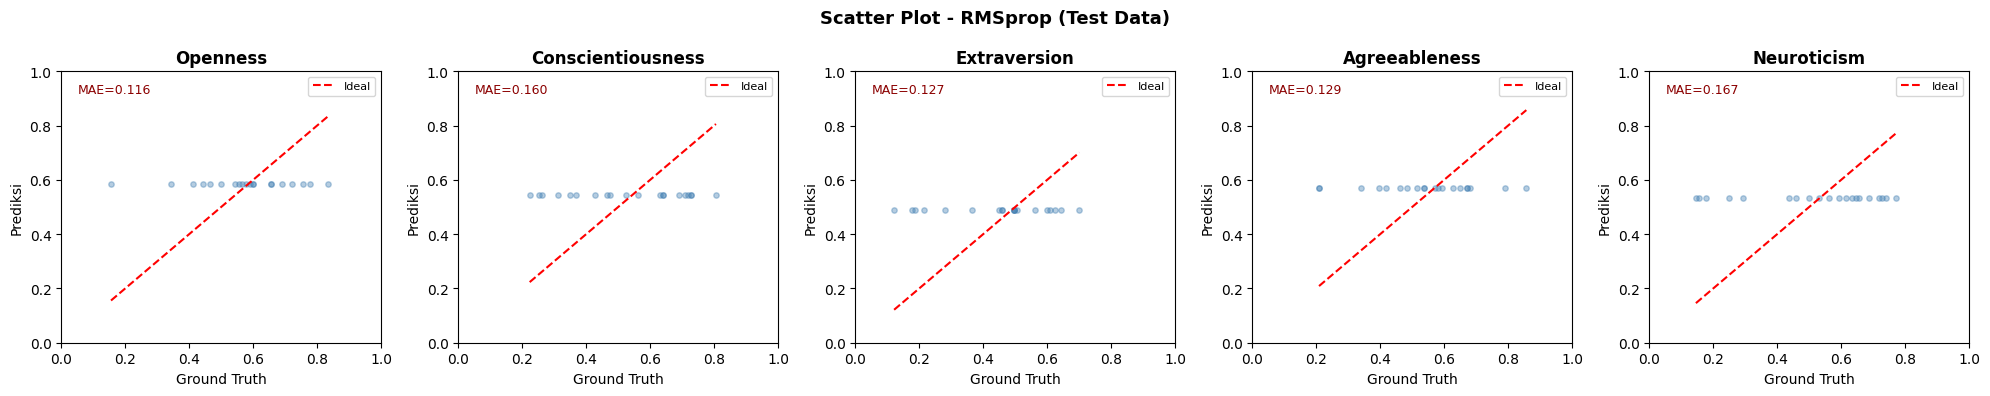

In [18]:
# ── [Eval 2] Scatter Plot: Prediksi vs Ground Truth (Test Data) ───────────
import matplotlib.pyplot as plt

test_ds_sc = tf.data.Dataset.load(r'data\\videoface_100\\test_ds')
y_true_all = np.concatenate([y.numpy() for _, y in test_ds_sc])
y_pred_all = model.predict(test_ds_sc, verbose=0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Scatter Plot - RMSprop (Test Data)', fontsize=13, fontweight='bold')

for i, (ax, trait) in enumerate(zip(axes, TRAITS)):
    yt = y_true_all[:, i]; yp = y_pred_all[:, i]
    ax.scatter(yt, yp, alpha=0.4, s=15, color='steelblue')
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
    ax.set_title(trait, fontweight='bold'); ax.set_xlabel('Ground Truth'); ax.set_ylabel('Prediksi')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)
    ax.text(0.05, 0.92, f'MAE={np.abs(yt-yp).mean():.3f}', transform=ax.transAxes, fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig('scatter_rmsprop.png', dpi=120, bbox_inches='tight')
plt.show()


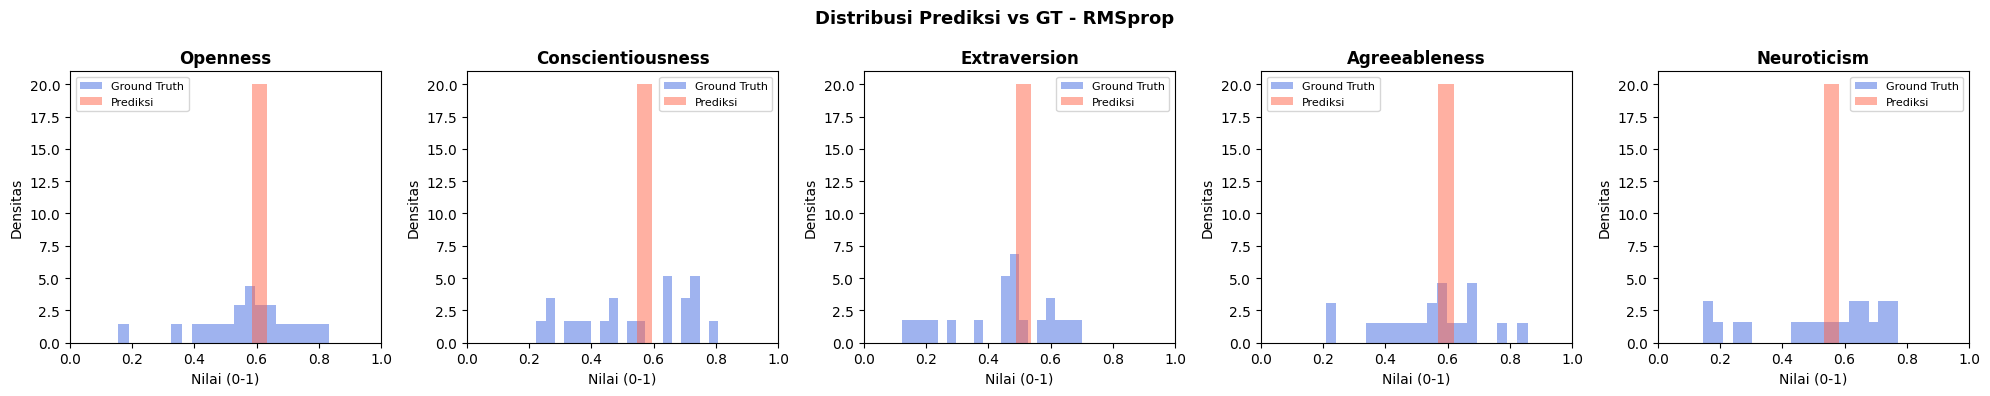

CATATAN: Jika prediksi menumpuk di satu titik -> model STUCK.


In [19]:
# ── [Eval 3] Histogram: Distribusi Prediksi vs Ground Truth ───────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Distribusi Prediksi vs GT - RMSprop', fontsize=13, fontweight='bold')

for i, (ax, trait) in enumerate(zip(axes, TRAITS)):
    ax.hist(y_true_all[:, i], bins=20, alpha=0.5, color='royalblue', label='Ground Truth', density=True)
    ax.hist(y_pred_all[:, i], bins=20, alpha=0.5, color='tomato',    label='Prediksi',     density=True)
    ax.set_title(trait, fontweight='bold'); ax.set_xlabel('Nilai (0-1)'); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8); ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('histogram_rmsprop.png', dpi=120, bbox_inches='tight')
plt.show()
print('CATATAN: Jika prediksi menumpuk di satu titik -> model STUCK.')


In [20]:
# ── [Eval 4] Training Summary ───────────────────────────────────────────────
val_maes   = history.history['val_mae']
best_epoch = int(np.argmin(val_maes)) + 1
best_val   = min(val_maes)
last_epoch = len(val_maes)

print('=' * 45)
print('         TRAINING SUMMARY')
print('=' * 45)
print('  Notebook        : 02_Face_Optimizer_RMS')
print('  Optimizer       : RMSprop')
print(f'  Total Epoch     : {last_epoch}')
print(f'  Best Epoch      : {best_epoch}')
print(f'  Best Val MAE    : {best_val:.4f}')
print(f'  Best Val Acc    : {(1-best_val)*100:.2f}%')
print(f'  Test MAE (rata) : {mae_te.mean():.4f}')
print(f'  Test Acc (rata) : {acc_te.mean():.2f}%')
print('=' * 45)
print()
print('Per Trait Test Accuracy:')
for trait, acc in zip(TRAITS, acc_te):
    bar = '#' * int(acc / 5)
    print(f'  {trait:18s}: {acc:5.2f}% |{bar}')


         TRAINING SUMMARY
  Notebook        : 02_Face_Optimizer_RMS
  Optimizer       : RMSprop
  Total Epoch     : 60
  Best Epoch      : 50
  Best Val MAE    : 0.1172
  Best Val Acc    : 88.28%
  Test MAE (rata) : 0.1397
  Test Acc (rata) : 86.03%

Per Trait Test Accuracy:
  Openness          : 88.44% |#################
  Conscientiousness : 84.03% |################
  Extraversion      : 87.31% |#################
  Agreeableness     : 87.09% |#################
  Neuroticism       : 83.29% |################
